In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

# !pip3 install pyramid-arima


# Import Data
df = pd.read_csv('https://github.com/selva86/datasets/raw/master/AirPassengers.csv')

In [2]:
df = pd.read_csv(r"C:\Users\Hp\Desktop\Python Code\Time Series - Student\Python\ARIMA\AirPassengers.csv")

df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


<Axes: xlabel='date'>

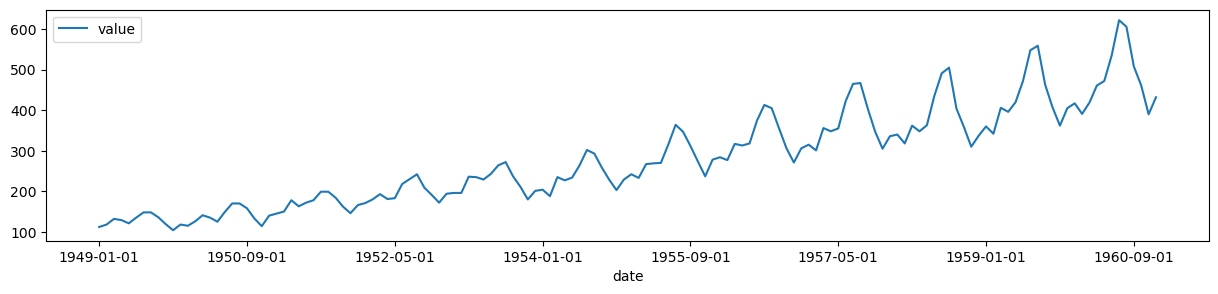

In [3]:
df.plot.line(x = 'date',y = 'value',figsize=(15,3))

* As per above pattern -- it is non-stationary

# Stationary  -- ADF Test 

* H0 : - The data is  non-stationary
* H1 : - The data is  stationary

* Alpha = 0.05 


In [4]:
from statsmodels.tsa.stattools import adfuller
dftest = adfuller(df['value'])
dfoutput = pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
dfoutput

Test Statistic                   0.815369
p-value                          0.991880
#lags used                      13.000000
number of observations used    130.000000
dtype: float64

* we do not Reject Ho
* The data is  non-stationary

# Differencing  ( d )

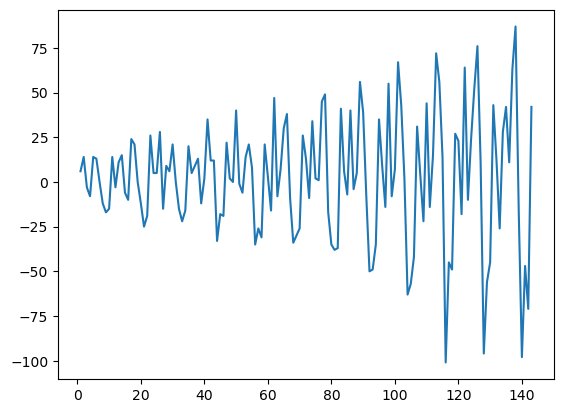

In [5]:
from matplotlib import pyplot

diff = df.value.diff()
pyplot.plot(diff)
pyplot.show()

In [6]:
df['diff_1'] = df['value'].diff()  # 1st order
df['diff_2'] = df['diff_1'].diff() # 2nd order

df

,date,value,diff_1,diff_2
0,1949-01-01,112,NaN,NaN
1,1949-02-01,118,6.0,NaN
2,1949-03-01,132,14.0,8.0
3,1949-04-01,129,-3.0,-17.0
4,1949-05-01,121,-8.0,-5.0
...,...,...,...,...
139,1960-08-01,606,-16.0,-103.0
140,1960-09-01,508,-98.0,-82.0
141,1960-10-01,461,-47.0,51.0
142,1960-11-01,390,-71.0,-24.0


In [7]:
import numpy as np
np.var(df)  # d = 1

value     14291.973331
diff_1     1131.384029
diff_2     1577.287840
dtype: float64

In [8]:
from statsmodels.tsa.stattools import adfuller
print("Observations of Dickey-fuller test")
dftest = adfuller(df.diff_1.loc[1:,])
dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
dfoutput

Observations of Dickey-fuller test


Test Statistic                  -2.829267
p-value                          0.054213
#lags used                      12.000000
number of observations used    130.000000
dtype: float64

* We Reject Ho
* The data is stationary

# ACF & PACF Plot

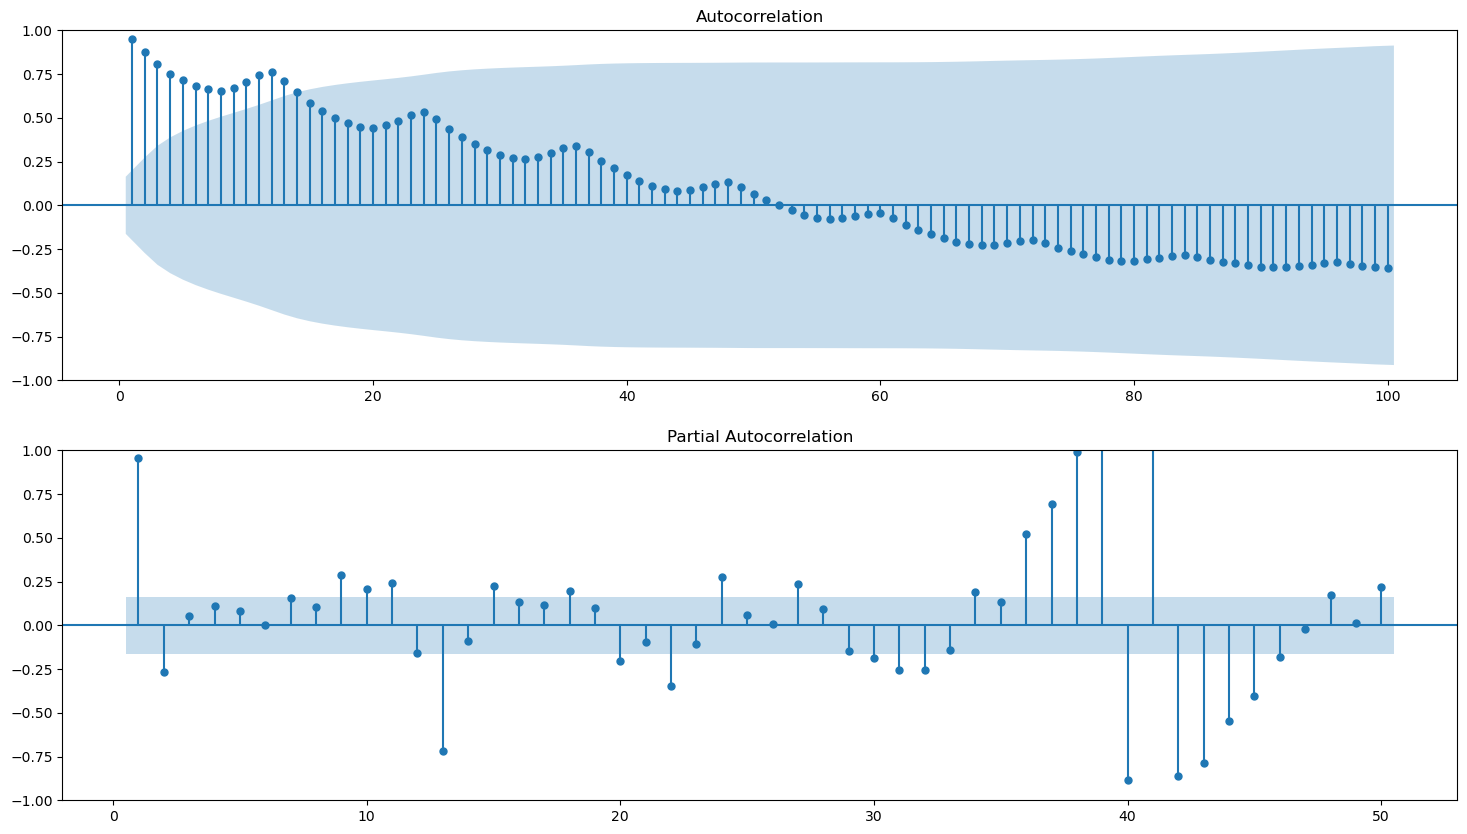

In [9]:
f, ax = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
plot_acf(df['value'],lags=100, ax=ax[0],zero=False)
plot_pacf(df['value'],lags=50, ax=ax[1],zero=False)
plt.show()

* Order (p,d,q) = (2,1,0)

# ARIMA MODEL - Manual 

from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
model = ARIMA(df.value,
                      start_p=0,max_p=3, # Pacf(p) = 0,1,2,3
                      d=0,max_d=2,       # Difference (d) = 0,1,2
                      start_q=0,max_q=3, # acf (q) = 0,1,2,3
                      m=12,              # frequency of series
                      seasonal=False,    # No Seasonality  then below P,D,Q will not be used 
                      start_P=0,max_P=2,
                      D=0,max_D=1,
                      start_Q=0,max_Q=2,
                      test='adf',       # use adftest to find optimal 'd'
                      trace=True)

# ARIMA MODEL -- Auto ( Grid Search )

In [10]:
df

,date,value,diff_1,diff_2
0,1949-01-01,112,NaN,NaN
1,1949-02-01,118,6.0,NaN
2,1949-03-01,132,14.0,8.0
3,1949-04-01,129,-3.0,-17.0
4,1949-05-01,121,-8.0,-5.0
...,...,...,...,...
139,1960-08-01,606,-16.0,-103.0
140,1960-09-01,508,-98.0,-82.0
141,1960-10-01,461,-47.0,51.0
142,1960-11-01,390,-71.0,-24.0


In [11]:
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
model = pm.auto_arima(df.value,
                      start_p=0,max_p=3, # Pacf(p) = 0,1,2,3
                      d=0,max_d=2,       # Difference (d) = 0,1,2
                      start_q=0,max_q=3, # acf (q) = 0,1,2,3
                      m=12,              # frequency of series
                      seasonal=False,    # No Seasonality  then below P,D,Q will not be used 
                      test='adf',       # use adftest to find optimal 'd'
                      trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2057.847, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1412.973, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1410.569, Time=0.20 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1417.450, Time=0.11 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1411.319, Time=0.29 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1411.135, Time=0.16 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1413.093, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.35 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1408.249, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1409.748, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1413.639, Time=0.14 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1408.287, T

# Fitted Value

In [12]:
import numpy as np
df['Forecast']=np.round(model.predict_in_sample(),0)
df.iloc[:,[0,1,4]]

,date,value,Forecast
0,1949-01-01,112,282.0
1,1949-02-01,118,118.0
2,1949-03-01,132,127.0
3,1949-04-01,129,140.0
4,1949-05-01,121,132.0
...,...,...,...
139,1960-08-01,606,618.0
140,1960-09-01,508,580.0
141,1960-10-01,461,473.0
142,1960-11-01,390,459.0


# Model plot

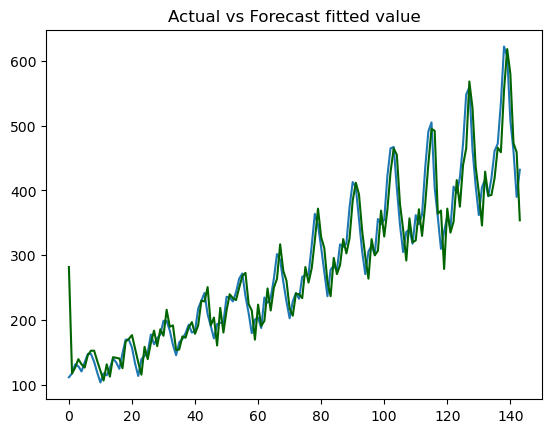

In [13]:
# Plot
plt.plot(df.value)
plt.plot(df.Forecast, color='darkgreen')
plt.title("Actual vs Forecast fitted value")
plt.show()

# Accuracy metrics


In [14]:
def forecast_accuracy(actual,forecast):
    mape = (np.mean(np.abs(actual-forecast)/np.abs(actual)))*100  # MAPE
    return({'mape':mape})

forecast_accuracy(df.value,df.Forecast)

{'mape': 9.551601916121353}

#  Forecast - Future Month


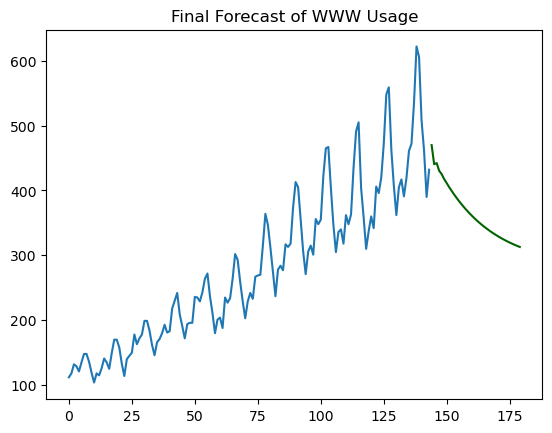

In [15]:
n_periods=36
fc = model.predict(n_periods=n_periods)

index_of_fc = np.arange(len(df.value), len(df.value)+n_periods)

# make series for plotting purpose
fc_series = pd.Series(fc, index=index_of_fc)

# Plot
plt.plot(df.value)
plt.plot(fc_series, color='darkgreen')
plt.title("Final Forecast of WWW Usage")
plt.show()

In [16]:
fc

144    470.010922
145    440.513917
146    442.191898
147    430.304302
148    425.095923
149    417.368502
150    411.265407
151    404.886189
152    399.069908
153    393.415430
154    388.084547
155    382.984949
156    378.140367
157    373.522822
158    369.128587
159    364.943735
160    360.959706
161    357.166222
162    353.554459
163    350.115581
164    346.841373
165    343.723921
166    340.755734
167    337.929659
168    335.238894
169    332.676960
170    330.237689
171    327.915207
172    325.703924
173    323.598514
174    321.593909
175    319.685283
176    317.868040
177    316.137804
178    314.490411
179    312.921893
dtype: float64

# SARIMAX -- Auto ( Grid Search )

In [17]:
from statsmodels.tsa.arima_model import ARIMA
import pmdarima as pm
smodel = pm.auto_arima(df.value,
                      start_p=0,max_p=3, # Pacf(p) = 0,1,2,3
                      d=0,max_d=2,       # Difference (d) = 0,1,2
                      start_q=0,max_q=3, # acf (q) = 0,1,2,3
                      m=12,              # frequency of series or time
                      seasonal=True,     # Seasonality is True then below P,D,Q will be used 
                      start_P=0,max_P=2, # P= 0,1,2
                      D=0,max_D=1,       # D = 0,1
                      start_Q=0,max_Q=2, # Q = 0,1,2
                      test='adf',       # use adftest to find optimal 'd'
                      trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1790.368, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2057.847, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1428.179, Time=0.09 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=1315.686, Time=0.38 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=1162.951, Time=0.55 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.95 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=1163.868, Time=1.15 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.76 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=1.12 s

# Fitted Value

In [18]:
df['S_Forecast'] = smodel.predict_in_sample()
df.iloc[:,[0,1,5]]

,date,value,S_Forecast
0,1949-01-01,112,0.000000
1,1949-02-01,118,110.635337
2,1949-03-01,132,114.922624
3,1949-04-01,129,125.069985
4,1949-05-01,121,127.069307
...,...,...,...
139,1960-08-01,606,626.109057
140,1960-09-01,508,512.488150
141,1960-10-01,461,450.496694
142,1960-11-01,390,409.520637


# Model plot

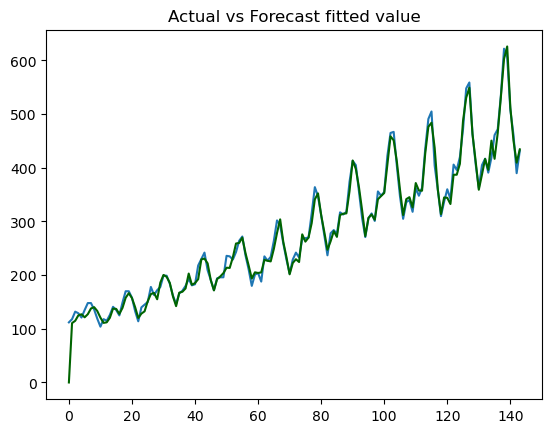

In [19]:
# Plot
plt.plot(df.value)
plt.plot(df.S_Forecast, color='darkgreen')
plt.title("Actual vs Forecast fitted value")
plt.show()

# Accuracy metrics


In [20]:
def forecast_accuracy(actual,forecast):
    mape = (np.mean(np.abs(actual-forecast)/np.abs(actual)))*100  # MAPE
    return({'mape':mape})

forecast_accuracy(df.value,df.S_Forecast)

{'mape': 4.112639891308379}

#  Forecast


In [21]:
n_periods=36
future_Forecast = smodel.predict(n_periods=n_periods)
future_Forecast

144    443.957350
145    417.455589
146    452.883073
147    480.804719
148    495.141271
149    556.357273
150    640.718511
151    631.543765
152    528.777021
153    478.511077
154    412.183515
155    452.585984
156    464.705822
157    436.353153
158    469.706389
159    500.436286
160    514.888663
161    575.629227
162    661.950454
163    651.440924
164    545.903509
165    495.694586
166    427.437248
167    467.467520
168    479.286974
169    449.577594
170    480.764811
171    513.958795
172    528.456590
173    588.368988
174    675.955507
175    664.310851
176    556.961610
177    507.193890
178    437.646722
179    477.082122
dtype: float64

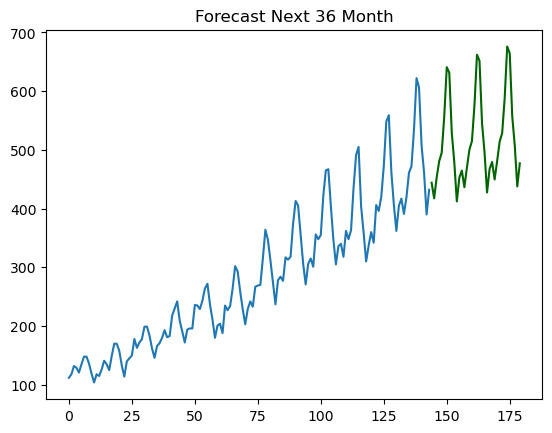

In [22]:
index_of_future_Forecast = np.arange(len(df.value), len(df.value)+n_periods)

# make series for plotting purpose
fc_series = pd.Series(future_Forecast, index=index_of_future_Forecast)

# Plot
plt.plot(df.value)
plt.plot(fc_series, color='darkgreen')
plt.title("Forecast Next 36 Month")
plt.show()

# Finished